In [20]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture # jaxxx??? # Hyakkk
from sklearn.decomposition import SparsePCA
from scipy.io import loadmat
import h5py
from scipy import sparse, linalg
from scipy.optimize import curve_fit, root
from scipy.integrate import odeint
from scipy.interpolate import interp1d
#from scipy.signal import convolve2d, fftconvolve # check jax
import os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

from jax.scipy.signal import fftconvolve
import math
import time

import pickle

import matplotlib as mpl
from matplotlib.colors import ListedColormap

import jax
jax.config.update("jax_enable_x64", True)
from jax import numpy as jnp
from jax import jit ,vmap
from jax.scipy.integrate import trapezoid as jtrap

# Seaborn colormap
import seaborn as sns
sns_list = sns.color_palette('deep').as_hex()
sns_list.insert(0, '#ffffff')  # Insert white at zero position

sns_cmap = ListedColormap(sns_list)
cm = sns_cmap


mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']


In [21]:
# UW_gold = '#C79900'
# faded_gold = '#D1AF62'

# UW_purple = '#4b2E83'
# faded_purple = '#D5D3FF'


UW_purple = '#C79900'
faded_purple = '#D1AF62'

UW_gold = '#4b2E83'
faded_gold = '#D5D3FF'


# Import Error for optimal hyperparameters for both Weak and Pointwise DB

Recall, this is the weighted error, so that incorrect terms at each point only weight towards the error as large as the surrounding cell is. This way the many inflation layers near the wall don't make the performance of the method in freestream or intertial region inconsequential.

In [22]:
ptws_pct_err_arr = []
ptws_noises = np.array([0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1.0])
# optimal_alpha_arr = np.array([187.5, 1.2, 7.5, 5.0, 175.0, 250.0, 187.5])
optimal_alpha_arr = np.array([50.0, 11.0, 112.5, 200.0, 1.0, 1.4, 4.0])

ptws_no_runs = 100
for i,noise in enumerate(ptws_noises):
    ptws_pct_err_arr.append(np.load(f'pointwise/error_data/ARI_Error{noise}_Noise_{optimal_alpha_arr[i]}_alpha_pct_arr.npy'))
ptws_pct_err_arr = np.array(ptws_pct_err_arr)

In [23]:
weak_noises = np.array([0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1.0])
corresponding_selected_supports = np.array([(0.3,0.2), (0.8,0.15), (1.2,0.12), (4.0,0.12), (2.0,0.4),(12.0,0.3), (12.0,0.3)])
corresponding_selected_alphas = np.array([5.5, 10.0, 7.5, 40.0, 55.0, 200.0, 220.0])
no_runs_Weak = 100

weak_pct_err_arr = []

for i,noise in enumerate(weak_noises):
    support_bound_x = corresponding_selected_supports[i,0]
    support_bound_y = corresponding_selected_supports[i,1]
    alpha = corresponding_selected_alphas[i]
    weak_pct_err_arr.append(np.load(f'weak/Error_Data/Noise_{noise}_support_{support_bound_x}_{support_bound_y}_alpha_{alpha}_noRunsWeak_{no_runs_Weak}_ARI_Error.npy'))
weak_pct_err_arr = np.array(weak_pct_err_arr)

In [24]:
# We want to plot the distributions side by side instead of overlapping
# Side-by-side offset in log10 space (half a bar spacing)
log_offset = 0.08

# Shift x locations in log space
ptws_x = ptws_noises * 10**(-log_offset+0.008)
weak_x = weak_noises * 10**(log_offset)

# Choose a fixed width in log10 space (e.g., 0.2 decades)
log_width = 0.14

# Compute actual widths in linear space so the log-width appears constant
widths = [10**(np.log10(x) + log_width / 2) - 10**(np.log10(x) - log_width / 2) for x in ptws_x]

# Compute actual widths in linear space so the log-width appears constant
weak_widths = [10**(np.log10(x) + log_width / 2) - 10**(np.log10(x) - log_width / 2) for x in weak_x]

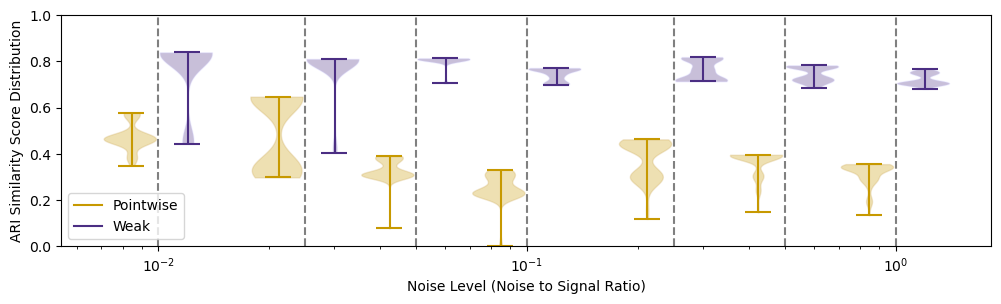

In [25]:
plt.figure(figsize=(12,3))
vp = plt.violinplot(ptws_pct_err_arr.T,positions=ptws_x,widths=widths,showmeans=False)

#Setcolors
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(UW_purple)
    body.set_edgecolor(faded_purple)
    # body.set_alpha(0.7) # Optional: set transparency

for partname in ('cbars', 'cmins', 'cmaxes'):
    vp[partname].set_edgecolor(UW_purple)
    # vp[partname].set_linewidth(1) # Optional: set line width

plt.plot(ptws_x[0],np.median(ptws_pct_err_arr,axis=1)[0], label = 'Pointwise', color=UW_purple)




vp = plt.violinplot(weak_pct_err_arr.T,positions=weak_x,widths=weak_widths,showmeans=False)#, quantiles=[[0.25,0.75],[0.25,0.75],[0.25,0.75],[0.25,0.75],[0.25,0.75],[0.25,0.75],[0.25,0.75]])#, label = 'Weak'
#Setcolors
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(UW_gold)
    body.set_edgecolor(faded_gold)
    # body.set_alpha(0.7) # Optional: set transparency
for partname in ('cbars', 'cmins', 'cmaxes'):
    vp[partname].set_edgecolor(UW_gold)

plt.plot(weak_x[0],np.median(weak_pct_err_arr,axis=1)[0], label = 'Weak', color=UW_gold)

for noise_level in weak_noises:
    plt.plot([noise_level, noise_level], [0.0,1.0], linestyle='--', color='grey')


plt.xscale('log')
# plt.title('Median, Distribution, Max/Min of Error for Weak vs Pointwise Dominant Balance')
plt.xlabel('Noise Level (Noise to Signal Ratio)')
plt.ylabel(r'ARI Similarity Score Distribution')
plt.ylim(0.0,1.0)
plt.legend(loc = "lower left")
plt.savefig('ARI_ViolinPlot.png',dpi=720,bbox_inches='tight')
plt.show()

In [26]:
ptws_pct_err_arr = []
ptws_noises = np.array([0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1.0])
# optimal_alpha_arr = np.array([187.5, 1.2, 7.5, 5.0, 175.0, 250.0, 187.5])
optimal_alpha_arr = np.array([50.0, 11.0, 112.5, 200.0, 1.0, 1.4, 4.0])

ptws_no_runs = 100
for i,noise in enumerate(ptws_noises):
    ptws_pct_err_arr.append(np.load(f'pointwise/error_data/NMI_Error_arr_{noise}_Noise_{optimal_alpha_arr[i]}_alpha.npy'))
ptws_pct_err_arr = np.array(ptws_pct_err_arr)

In [27]:
weak_noises = np.array([0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1.0])
corresponding_selected_supports = np.array([(0.3,0.2), (0.8,0.15), (1.2,0.12), (4.0,0.12), (2.0,0.4),(12.0,0.3), (12.0,0.3)])
corresponding_selected_alphas = np.array([5.5, 10.0, 7.5, 40.0, 55.0, 200.0, 220.0])
no_runs_Weak = 100

weak_pct_err_arr = []

for i,noise in enumerate(weak_noises):
    support_bound_x = corresponding_selected_supports[i,0]
    support_bound_y = corresponding_selected_supports[i,1]
    alpha = corresponding_selected_alphas[i]
    weak_pct_err_arr.append(np.load(f'weak/Error_Data/Noise_{noise}_support_{support_bound_x}_{support_bound_y}_alpha_{alpha}_noRunsWeak_{no_runs_Weak}_NMI_Error.npy'))
weak_pct_err_arr = np.array(weak_pct_err_arr)

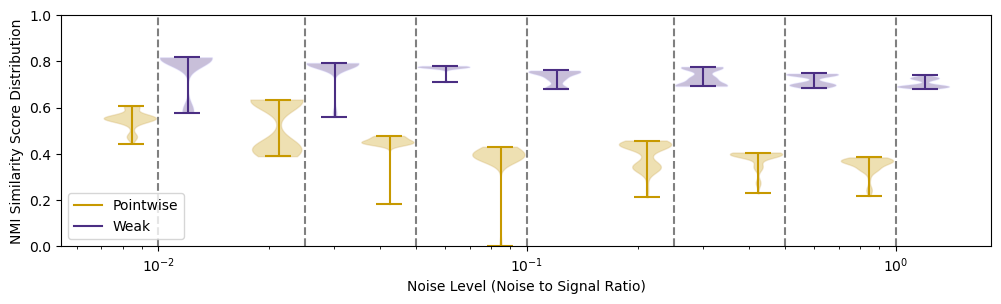

In [28]:
plt.figure(figsize=(12,3))
vp = plt.violinplot(ptws_pct_err_arr.T,positions=ptws_x,widths=widths,showmeans=False)

#Setcolors
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(UW_purple)
    body.set_edgecolor(faded_purple)
    # body.set_alpha(0.7) # Optional: set transparency

for partname in ('cbars', 'cmins', 'cmaxes'):
    vp[partname].set_edgecolor(UW_purple)

plt.plot(ptws_x[0],np.median(ptws_pct_err_arr,axis=1)[0], label = 'Pointwise', color=UW_purple)

vp = plt.violinplot(weak_pct_err_arr.T,positions=weak_x,widths=weak_widths,showmeans=False)
#Setcolors
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(UW_gold)
    body.set_edgecolor(faded_gold)
    # body.set_alpha(0.7) # Optional: set transparency
for partname in ('cbars', 'cmins', 'cmaxes'):
    vp[partname].set_edgecolor(UW_gold)

plt.plot(weak_x[0],np.median(weak_pct_err_arr,axis=1)[0], label = 'Weak', color=UW_gold)

for noise_level in weak_noises:
    plt.plot([noise_level, noise_level], [0.0,1.0], linestyle='--', color='grey')


plt.xscale('log')
# plt.title('Median, Distribution, Max/Min of Error for Weak vs Pointwise Dominant Balance')
plt.xlabel('Noise Level (Noise to Signal Ratio)')
plt.ylabel(r'NMI Similarity Score Distribution')
plt.ylim(0.0,1.0)
plt.legend(loc = "lower left")
plt.savefig('NMI_ViolinPlot.png',dpi=720,bbox_inches='tight')
plt.show()